# Minh hoạ bài toán dự đoán cấu trúc gen bằng Hidden Markov Model

Notebook này xây dựng một mô hình HMM từ đầu để phân đoạn chuỗi DNA thành:

- vùng **intergenic**;
- **start codon**;
- vùng **coding/exon** với chu kỳ ba nucleotide;
- **donor splice site**;
- **intron**;
- **acceptor splice site**;
- **stop codon**.

Mục tiêu chính là hiểu rõ cách ánh xạ một bài toán sinh học sang HMM, cách ước lượng tham số từ dữ liệu có nhãn và cách dùng thuật toán Viterbi để tìm cấu trúc gen có xác suất lớn nhất.

> Phạm vi minh hoạ: mỗi gen có tối đa một intron phase 0 và dùng start codon `ATG`, stop codon `TAA`. Đây là mô hình sư phạm, không phải hệ thống chú thích genome hoàn chỉnh.

## 1. Mục tiêu học tập

Sau khi chạy hết notebook, bạn có thể:

1. Phát biểu bài toán gene finding dưới dạng sequence labeling.
2. Xác định observation, hidden state, transition và emission.
3. Xây dựng topology HMM chứa các ràng buộc sinh học.
4. Sinh dữ liệu DNA tổng hợp có ground truth.
5. Ước lượng ma trận chuyển trạng thái và xác suất phát xạ.
6. Cài đặt Viterbi trong miền log-probability.
7. Đánh giá dự đoán ở mức nucleotide và mức ranh giới gen.
8. Hiểu cách mở rộng sang GHMM/HSMM và dữ liệu FASTA–GFF thực.

## 2. Kiến thức sinh học tối thiểu

Một gen mã hoá protein thường chứa các thành phần:

\[
\text{Intergenic}
\rightarrow
\text{Start codon}
\rightarrow
\text{Exon/CDS}
\rightarrow
\text{Intron}
\rightarrow
\text{Exon/CDS}
\rightarrow
\text{Stop codon}
\rightarrow
\text{Intergenic}
\]

Các tín hiệu thường gặp:

- Start codon: `ATG`.
- Stop codon: `TAA`, `TAG`, `TGA`.
- Donor splice site: thường bắt đầu bằng `GT`.
- Acceptor splice site: thường kết thúc bằng `AG`.
- Vùng coding có chu kỳ ba nucleotide vì protein được dịch theo codon.

Trong notebook này, intron chỉ xuất hiện giữa hai codon hoàn chỉnh, tức **phase 0**:

```text
... codon | GT ... intron ... AG | codon ...
```

Mô hình đầy đủ cần thêm intron phase 1 và phase 2 để xử lý intron cắt sau nucleotide thứ nhất hoặc thứ hai của codon.

## 3. Phát biểu bài toán dưới dạng HMM

### Quan sát

Chuỗi DNA:

\[
X=(x_1,x_2,\ldots,x_T), \qquad x_t\in\{A,C,G,T\}
\]

### Trạng thái ẩn

Chuỗi nhãn sinh học:

\[
Z=(z_1,z_2,\ldots,z_T)
\]

Ví dụ:

```text
DNA:    A C T A T G G C A ... G T ... A G C C T T A A
State:  I I I S1 S2 S3 E1 ... D1 D2 ... A1 A2 E1 ... P1 P2 P3
```

### Các tham số HMM

\[
\lambda=(\pi,A,B)
\]

Trong đó:

- \(\pi_i=P(z_1=i)\): xác suất trạng thái ban đầu;
- \(a_{ij}=P(z_t=j\mid z_{t-1}=i)\): xác suất chuyển trạng thái;
- \(b_i(x)=P(x_t=x\mid z_t=i)\): xác suất phát xạ nucleotide.

Xác suất đồng thời:

\[
P(X,Z)=
\pi_{z_1}
\prod_{t=2}^{T}a_{z_{t-1},z_t}
\prod_{t=1}^{T}b_{z_t}(x_t)
\]

Khi giải mã, ta tìm:

\[
Z^*=\arg\max_Z P(X,Z)
\]

## 4. Thiết kế topology HMM

Các trạng thái được dùng:

| Nhóm | Trạng thái | Ý nghĩa |
|---|---|---|
| Không mã hoá | `I` | Intergenic |
| Start | `S1,S2,S3` | Ba vị trí của `ATG` |
| Coding | `E1,E2,E3` | Ba vị trí trong codon |
| Donor | `D1,D2` | Hai nucleotide `GT` |
| Intron | `N` | Phần bên trong intron |
| Acceptor | `A1,A2` | Hai nucleotide `AG` |
| Stop | `P1,P2,P3` | Ba vị trí của `TAA` |

Các đường chuyển hợp lệ:

```text
I -> I hoặc S1
S1 -> S2 -> S3 -> E1
E1 -> E2 -> E3
E3 -> E1, D1 hoặc P1
D1 -> D2 -> N
N -> N hoặc A1
A1 -> A2 -> E1
P1 -> P2 -> P3 -> I
```

Điểm quan trọng là HMM không chỉ phân loại từng nucleotide. Topology còn ngăn các cấu trúc vô lý như:

```text
Intron -> Start codon
Stop codon -> Donor
Acceptor -> Intergenic
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from dataclasses import dataclass

RNG = np.random.default_rng(42)

BASES = ["A", "C", "G", "T"]

STATES = [
    "I",
    "S1", "S2", "S3",
    "E1", "E2", "E3",
    "D1", "D2",
    "N",
    "A1", "A2",
    "P1", "P2", "P3",
]

STATE_TO_IDX = {s: i for i, s in enumerate(STATES)}
IDX_TO_STATE = {i: s for s, i in STATE_TO_IDX.items()}

len(STATES), STATES

(15,
 ['I',
  'S1',
  'S2',
  'S3',
  'E1',
  'E2',
  'E3',
  'D1',
  'D2',
  'N',
  'A1',
  'A2',
  'P1',
  'P2',
  'P3'])

## 5. Xác định các transition được phép

Ta biểu diễn topology bằng một dictionary. Những transition không xuất hiện trong dictionary sẽ bị xem là không hợp lệ và nhận xác suất bằng 0.

In [2]:
ALLOWED_TRANSITIONS = {
    "I":  ["I", "S1"],
    "S1": ["S2"],
    "S2": ["S3"],
    "S3": ["E1"],
    "E1": ["E2"],
    "E2": ["E3"],
    "E3": ["E1", "D1", "P1"],
    "D1": ["D2"],
    "D2": ["N"],
    "N":  ["N", "A1"],
    "A1": ["A2"],
    "A2": ["E1"],
    "P1": ["P2"],
    "P2": ["P3"],
    "P3": ["I"],
}

for s in STATES:
    assert s in ALLOWED_TRANSITIONS

ALLOWED_TRANSITIONS

{'I': ['I', 'S1'],
 'S1': ['S2'],
 'S2': ['S3'],
 'S3': ['E1'],
 'E1': ['E2'],
 'E2': ['E3'],
 'E3': ['E1', 'D1', 'P1'],
 'D1': ['D2'],
 'D2': ['N'],
 'N': ['N', 'A1'],
 'A1': ['A2'],
 'A2': ['E1'],
 'P1': ['P2'],
 'P2': ['P3'],
 'P3': ['I']}

## 6. Mô hình phát xạ dùng để sinh dữ liệu tổng hợp

Ta chủ động chọn các phân phối nucleotide khác nhau để mô phỏng:

- intergenic;
- ba pha coding;
- intron;
- các motif cố định.

Các phân phối dưới đây chỉ dùng để tạo dữ liệu minh hoạ. Sau đó HMM sẽ phải học lại các tham số từ dữ liệu train.

In [3]:
EMISSION_GENERATOR = {
    "I":  {"A": 0.35, "C": 0.15, "G": 0.15, "T": 0.35},
    "S1": {"A": 1.00, "C": 0.00, "G": 0.00, "T": 0.00},
    "S2": {"A": 0.00, "C": 0.00, "G": 0.00, "T": 1.00},
    "S3": {"A": 0.00, "C": 0.00, "G": 1.00, "T": 0.00},
    "E1": {"A": 0.15, "C": 0.15, "G": 0.50, "T": 0.20},
    "E2": {"A": 0.45, "C": 0.20, "G": 0.15, "T": 0.20},
    "E3": {"A": 0.15, "C": 0.45, "G": 0.20, "T": 0.20},
    "D1": {"A": 0.00, "C": 0.00, "G": 1.00, "T": 0.00},
    "D2": {"A": 0.00, "C": 0.00, "G": 0.00, "T": 1.00},
    "N":  {"A": 0.40, "C": 0.10, "G": 0.10, "T": 0.40},
    "A1": {"A": 1.00, "C": 0.00, "G": 0.00, "T": 0.00},
    "A2": {"A": 0.00, "C": 0.00, "G": 1.00, "T": 0.00},
    "P1": {"A": 0.00, "C": 0.00, "G": 0.00, "T": 1.00},
    "P2": {"A": 1.00, "C": 0.00, "G": 0.00, "T": 0.00},
    "P3": {"A": 1.00, "C": 0.00, "G": 0.00, "T": 0.00},
}

def sample_base(state, rng=RNG):
    probs = np.array([EMISSION_GENERATOR[state][b] for b in BASES], dtype=float)
    return rng.choice(BASES, p=probs)

pd.DataFrame(EMISSION_GENERATOR).T

,A,C,G,T
I,0.35,0.15,0.15,0.35
S1,1.00,0.00,0.00,0.00
S2,0.00,0.00,0.00,1.00
S3,0.00,0.00,1.00,0.00
E1,0.15,0.15,0.50,0.20
E2,0.45,0.20,0.15,0.20
E3,0.15,0.45,0.20,0.20
D1,0.00,0.00,1.00,0.00
D2,0.00,0.00,0.00,1.00
N,0.40,0.10,0.10,0.40


## 7. Sinh dữ liệu DNA có ground truth

Mỗi chuỗi tổng hợp gồm:

1. intergenic phía trước;
2. `ATG`;
3. một số codon coding;
4. tùy chọn một intron phase 0;
5. một số codon coding;
6. `TAA`;
7. intergenic phía sau.

Ta lưu song song:

- chuỗi nucleotide;
- chuỗi trạng thái thật;
- các ranh giới sinh học.

In [4]:
@dataclass
class SyntheticRecord:
    sequence: str
    states: list
    metadata: dict

def append_state_run(seq_parts, state_parts, state, length, rng):
    for _ in range(length):
        seq_parts.append(sample_base(state, rng))
        state_parts.append(state)

def generate_synthetic_gene(
    rng,
    prefix_range=(35, 70),
    suffix_range=(35, 70),
    exon1_codons_range=(10, 22),
    exon2_codons_range=(10, 22),
    intron_range=(25, 70),
    include_intron=True,
):
    seq, states = [], []

    prefix_len = int(rng.integers(prefix_range[0], prefix_range[1] + 1))
    suffix_len = int(rng.integers(suffix_range[0], suffix_range[1] + 1))
    exon1_codons = int(rng.integers(exon1_codons_range[0], exon1_codons_range[1] + 1))
    exon2_codons = int(rng.integers(exon2_codons_range[0], exon2_codons_range[1] + 1))

    append_state_run(seq, states, "I", prefix_len, rng)
    gene_start = len(seq)

    for s in ["S1", "S2", "S3"]:
        append_state_run(seq, states, s, 1, rng)

    for _ in range(exon1_codons):
        for s in ["E1", "E2", "E3"]:
            append_state_run(seq, states, s, 1, rng)

    intron_start = intron_end = None
    if include_intron:
        for s in ["D1", "D2"]:
            append_state_run(seq, states, s, 1, rng)

        intron_start = len(seq)
        intron_len = int(rng.integers(intron_range[0], intron_range[1] + 1))
        append_state_run(seq, states, "N", intron_len, rng)
        intron_end = len(seq) - 1

        for s in ["A1", "A2"]:
            append_state_run(seq, states, s, 1, rng)

    for _ in range(exon2_codons):
        for s in ["E1", "E2", "E3"]:
            append_state_run(seq, states, s, 1, rng)

    for s in ["P1", "P2", "P3"]:
        append_state_run(seq, states, s, 1, rng)

    gene_end = len(seq) - 1
    append_state_run(seq, states, "I", suffix_len, rng)

    return SyntheticRecord(
        sequence="".join(seq),
        states=states,
        metadata={
            "gene_start": gene_start,
            "gene_end": gene_end,
            "intron_start": intron_start,
            "intron_end": intron_end,
            "has_intron": include_intron,
        },
    )

example = generate_synthetic_gene(np.random.default_rng(1), include_intron=True)

len(example.sequence), example.metadata

(268,
 {'gene_start': 52,
  'gene_end': 214,
  'intron_start': 114,
  'intron_end': 143,
  'has_intron': True})

In [5]:
def show_region(record, start, end):
    start = max(0, start)
    end = min(len(record.sequence), end)
    return pd.DataFrame({
        "pos": np.arange(start, end),
        "base": list(record.sequence[start:end]),
        "state": record.states[start:end],
    })

show_region(example, example.metadata["gene_start"] - 5, example.metadata["gene_start"] + 15)

,pos,base,state
0,47,T,I
1,48,T,I
2,49,T,I
3,50,A,I
4,51,T,I
5,52,A,S1
6,53,T,S2
7,54,G,S3
8,55,T,E1
9,56,T,E2


## 8. Tạo tập train, validation và test

Vì đây là dữ liệu tổng hợp, ta có thể tạo nhiều chuỗi độc lập.

Trong dữ liệu thật, nên chia train/validation/test theo chromosome hoặc contig. Không nên cắt ngẫu nhiên các đoạn gần nhau từ cùng một chromosome vì có thể gây data leakage.

In [6]:
def make_dataset(n, seed):
    rng = np.random.default_rng(seed)
    records = []
    for _ in range(n):
        include_intron = bool(rng.random() < 0.8)
        records.append(generate_synthetic_gene(rng, include_intron=include_intron))
    return records

train_records = make_dataset(300, seed=10)
val_records   = make_dataset(60, seed=20)
test_records  = make_dataset(80, seed=30)

sum(len(r.sequence) for r in train_records), len(test_records)

(74521, 80)

## 9. Ước lượng tham số HMM từ dữ liệu có nhãn

Với dữ liệu có annotation, ta có thể đếm trực tiếp.

### Transition

\[
\hat a_{ij}
=
\frac{N(i\rightarrow j)+\alpha}
{\sum_{k\in \mathcal A(i)}N(i\rightarrow k)+\alpha|\mathcal A(i)|}
\]

Trong đó \(\mathcal A(i)\) là tập transition được phép từ trạng thái \(i\).

### Emission

\[
\hat b_i(x)
=
\frac{N(i,x)+\beta}
{\sum_y N(i,y)+4\beta}
\]

Smoothing giúp tránh xác suất bằng 0 khi một nucleotide chưa xuất hiện trong tập train.

In [7]:
def estimate_hmm_supervised(records, alpha=0.5, beta=0.5):
    start_counts = Counter()
    transition_counts = defaultdict(Counter)
    emission_counts = defaultdict(Counter)

    for record in records:
        seq = record.sequence
        states = record.states

        start_counts[states[0]] += 1

        for base, state in zip(seq, states):
            emission_counts[state][base] += 1

        for s_prev, s_next in zip(states[:-1], states[1:]):
            if s_next not in ALLOWED_TRANSITIONS[s_prev]:
                raise ValueError(f"Transition không hợp lệ trong dữ liệu: {s_prev} -> {s_next}")
            transition_counts[s_prev][s_next] += 1

    # Initial probabilities
    pi = np.full(len(STATES), 1e-12, dtype=float)
    total_starts = sum(start_counts.values())
    for s in STATES:
        pi[STATE_TO_IDX[s]] = (start_counts[s] + alpha) / (total_starts + alpha * len(STATES))
    pi /= pi.sum()

    # Transition matrix
    A = np.zeros((len(STATES), len(STATES)), dtype=float)
    for s in STATES:
        allowed = ALLOWED_TRANSITIONS[s]
        denom = sum(transition_counts[s][t] for t in allowed) + alpha * len(allowed)
        for t in allowed:
            A[STATE_TO_IDX[s], STATE_TO_IDX[t]] = (
                transition_counts[s][t] + alpha
            ) / denom

    # Emission matrix
    B = np.zeros((len(STATES), len(BASES)), dtype=float)
    for s in STATES:
        total = sum(emission_counts[s][b] for b in BASES)
        denom = total + beta * len(BASES)
        for b_idx, b in enumerate(BASES):
            B[STATE_TO_IDX[s], b_idx] = (
                emission_counts[s][b] + beta
            ) / denom

    return pi, A, B

pi, A, B = estimate_hmm_supervised(train_records)

transition_df = pd.DataFrame(A, index=STATES, columns=STATES)
emission_df = pd.DataFrame(B, index=STATES, columns=BASES)

emission_df.round(3)

,A,C,G,T
I,0.350,0.151,0.152,0.347
S1,0.995,0.002,0.002,0.002
S2,0.002,0.002,0.002,0.995
S3,0.002,0.002,0.995,0.002
E1,0.149,0.152,0.500,0.199
E2,0.444,0.209,0.153,0.194
E3,0.146,0.456,0.196,0.201
D1,0.002,0.002,0.994,0.002
D2,0.002,0.002,0.002,0.994
N,0.407,0.099,0.102,0.392


In [8]:
# Chỉ hiển thị các transition có xác suất lớn hơn 0
nonzero_transitions = []
for i, s in enumerate(STATES):
    for j, t in enumerate(STATES):
        if A[i, j] > 0:
            nonzero_transitions.append((s, t, A[i, j]))

pd.DataFrame(nonzero_transitions, columns=["from", "to", "probability"]).round(4)

,from,to,probability
0,I,I,0.9904
1,I,S1,0.0096
2,S1,S2,1.0000
3,S2,S3,1.0000
4,S3,E1,1.0000
5,E1,E2,1.0000
6,E2,E3,1.0000
7,E3,E1,0.9429
8,E3,D1,0.0256
9,E3,P1,0.0315


## 10. Giải mã Viterbi

Viterbi tìm đường trạng thái có xác suất lớn nhất.

### Truy hồi

\[
V_t(j)
=
b_j(x_t)
\max_i[V_{t-1}(i)a_{ij}]
\]

Để tránh underflow, dùng log:

\[
\log V_t(j)
=
\log b_j(x_t)
+
\max_i[\log V_{t-1}(i)+\log a_{ij}]
\]

Ta cũng lưu backpointer để traceback đường đi tối ưu.

In [9]:
BASE_TO_IDX = {b: i for i, b in enumerate(BASES)}

def safe_log(x):
    out = np.full_like(x, -np.inf, dtype=float)
    mask = x > 0
    out[mask] = np.log(x[mask])
    return out

def viterbi_decode(sequence, pi, A, B):
    T = len(sequence)
    N = len(STATES)

    log_pi = safe_log(pi)
    log_A = safe_log(A)
    log_B = safe_log(B)

    dp = np.full((T, N), -np.inf, dtype=float)
    back = np.full((T, N), -1, dtype=int)

    first_base_idx = BASE_TO_IDX[sequence[0]]
    dp[0] = log_pi + log_B[:, first_base_idx]

    for t in range(1, T):
        base_idx = BASE_TO_IDX[sequence[t]]
        for j in range(N):
            candidate_scores = dp[t - 1] + log_A[:, j]
            best_prev = int(np.argmax(candidate_scores))
            best_score = candidate_scores[best_prev]

            if np.isfinite(best_score) and np.isfinite(log_B[j, base_idx]):
                dp[t, j] = best_score + log_B[j, base_idx]
                back[t, j] = best_prev

    last_state = int(np.argmax(dp[-1]))
    if not np.isfinite(dp[-1, last_state]):
        raise RuntimeError("Không tìm được đường Viterbi hợp lệ.")

    path = np.full(T, -1, dtype=int)
    path[-1] = last_state

    for t in range(T - 1, 0, -1):
        path[t - 1] = back[t, path[t]]
        if path[t - 1] < 0:
            raise RuntimeError("Backpointer không hợp lệ.")

    return [IDX_TO_STATE[i] for i in path], float(dp[-1, last_state])

pred_states, log_score = viterbi_decode(test_records[0].sequence, pi, A, B)

log_score, pred_states[:20]

(-310.4536956735307,
 ['I',
  'I',
  'I',
  'I',
  'I',
  'I',
  'I',
  'I',
  'I',
  'I',
  'I',
  'I',
  'I',
  'I',
  'I',
  'I',
  'I',
  'I',
  'I',
  'I'])

## 11. Đánh giá mức nucleotide

Ta tính:

- accuracy toàn bộ trạng thái;
- precision, recall, F1 cho từng trạng thái;
- macro F1.

Lưu ý: accuracy có thể gây hiểu nhầm nếu vùng intergenic chiếm quá nhiều. Vì vậy cần xem F1 theo lớp và các metric ở mức ranh giới.

In [10]:
def classification_report_custom(y_true, y_pred, labels):
    rows = []
    for label in labels:
        tp = sum(t == label and p == label for t, p in zip(y_true, y_pred))
        fp = sum(t != label and p == label for t, p in zip(y_true, y_pred))
        fn = sum(t == label and p != label for t, p in zip(y_true, y_pred))
        support = sum(t == label for t in y_true)

        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

        rows.append({
            "state": label,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support,
        })

    return pd.DataFrame(rows)

def evaluate_records(records, pi, A, B):
    y_true_all, y_pred_all = [], []
    decoded = []

    for record in records:
        pred, score = viterbi_decode(record.sequence, pi, A, B)
        y_true_all.extend(record.states)
        y_pred_all.extend(pred)
        decoded.append((record, pred, score))

    accuracy = np.mean(np.array(y_true_all) == np.array(y_pred_all))
    report = classification_report_custom(y_true_all, y_pred_all, STATES)
    macro_f1 = report["f1"].mean()

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "report": report,
        "decoded": decoded,
    }

test_eval = evaluate_records(test_records, pi, A, B)

test_eval["accuracy"], test_eval["macro_f1"]

(np.float64(0.9663029687896473), np.float64(0.9280648176223977))

In [11]:
test_eval["report"].round(3)

,state,precision,recall,f1,support
0,I,0.992,0.951,0.971,8317
1,S1,0.929,0.975,0.951,80
2,S2,0.929,0.975,0.951,80
3,S3,0.929,0.975,0.951,80
4,E1,0.980,0.976,0.978,2500
5,E2,0.980,0.976,0.978,2500
6,E3,0.980,0.976,0.978,2500
7,D1,0.824,0.924,0.871,66
8,D2,0.824,0.924,0.871,66
9,N,0.894,0.994,0.942,3144


## 12. Gom trạng thái thành các vùng sinh học lớn

Trong thực tế, đôi khi ta không cần phân biệt `E1`, `E2`, `E3` mà chỉ cần biết vị trí thuộc coding hay không.

Ta gom:

- `I` → INTERGENIC;
- `S*`, `E*`, `P*` → CODING;
- `D*`, `A*` → SPLICE_SIGNAL;
- `N` → INTRON.

In [12]:
def collapse_state(state):
    if state == "I":
        return "INTERGENIC"
    if state.startswith(("S", "E", "P")):
        return "CODING"
    if state.startswith(("D", "A")):
        return "SPLICE_SIGNAL"
    if state == "N":
        return "INTRON"
    raise ValueError(state)

collapsed_labels = ["INTERGENIC", "CODING", "SPLICE_SIGNAL", "INTRON"]

y_true_collapsed = []
y_pred_collapsed = []

for record, pred, _ in test_eval["decoded"]:
    y_true_collapsed.extend(map(collapse_state, record.states))
    y_pred_collapsed.extend(map(collapse_state, pred))

collapsed_report = classification_report_custom(
    y_true_collapsed,
    y_pred_collapsed,
    collapsed_labels,
)

collapsed_accuracy = np.mean(
    np.array(y_true_collapsed) == np.array(y_pred_collapsed)
)

collapsed_accuracy, collapsed_report.round(3)

(np.float64(0.9673686881502157),
            state  precision  recall     f1  support
 0     INTERGENIC      0.992   0.951  0.971     8317
 1         CODING      0.979   0.976  0.978     7980
 2  SPLICE_SIGNAL      0.840   0.917  0.877      264
 3         INTRON      0.894   0.994  0.942     3144)

## 13. Đánh giá ranh giới gen và intron

Một mô hình gene finding tốt không chỉ cần đúng phần lớn nucleotide mà còn cần đặt đúng:

- vị trí start codon;
- vị trí stop codon;
- donor;
- acceptor.

Ta trích các vị trí bắt đầu của từng trạng thái tín hiệu và tính precision/recall/F1.

In [13]:
def positions_of(state_sequence, target_state):
    return {i for i, s in enumerate(state_sequence) if s == target_state}

def boundary_prf(decoded, target_state):
    tp = fp = fn = 0
    for record, pred, _ in decoded:
        true_pos = positions_of(record.states, target_state)
        pred_pos = positions_of(pred, target_state)

        tp += len(true_pos & pred_pos)
        fp += len(pred_pos - true_pos)
        fn += len(true_pos - pred_pos)

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return {
        "boundary": target_state,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "fn": fn,
    }

boundary_states = ["S1", "D1", "A1", "P1"]
boundary_results = pd.DataFrame([
    boundary_prf(test_eval["decoded"], s) for s in boundary_states
])

boundary_results.round(3)

,boundary,precision,recall,f1,tp,fp,fn
0,S1,0.929,0.975,0.951,78,6,2
1,D1,0.824,0.924,0.871,61,13,5
2,A1,0.857,0.909,0.882,60,10,6
3,P1,0.922,0.888,0.904,71,6,9


## 14. Trực quan hoá một chuỗi test

Đồ thị dưới đây mã hoá mỗi trạng thái bằng một số nguyên. Hai đường trùng nhau nghĩa là dự đoán chính xác tại vị trí đó.

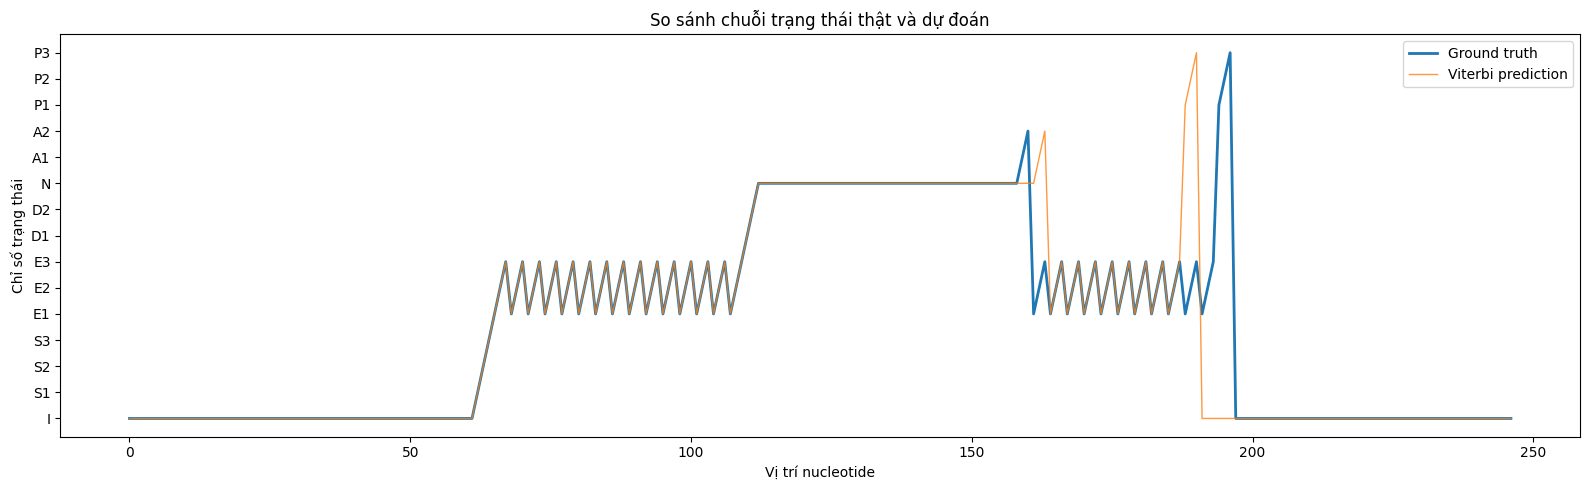

In [14]:
record, pred, score = test_eval["decoded"][0]

true_numeric = [STATE_TO_IDX[s] for s in record.states]
pred_numeric = [STATE_TO_IDX[s] for s in pred]

plt.figure(figsize=(16, 5))
plt.plot(true_numeric, label="Ground truth", linewidth=2)
plt.plot(pred_numeric, label="Viterbi prediction", linewidth=1, alpha=0.8)
plt.xlabel("Vị trí nucleotide")
plt.ylabel("Chỉ số trạng thái")
plt.title("So sánh chuỗi trạng thái thật và dự đoán")
plt.yticks(range(len(STATES)), STATES)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
comparison = pd.DataFrame({
    "pos": np.arange(len(record.sequence)),
    "base": list(record.sequence),
    "true_state": record.states,
    "pred_state": pred,
})
comparison["correct"] = comparison["true_state"] == comparison["pred_state"]

comparison.loc[
    max(0, record.metadata["gene_start"] - 8):
    record.metadata["gene_start"] + 20
]

,pos,base,true_state,pred_state,correct
54,54,G,I,I,True
55,55,A,I,I,True
56,56,C,I,I,True
57,57,G,I,I,True
58,58,A,I,I,True
59,59,T,I,I,True
60,60,T,I,I,True
61,61,T,I,I,True
62,62,A,S1,S1,True
63,63,T,S2,S2,True


## 15. So sánh với bộ phân loại độc lập từng nucleotide

Nếu bỏ transition và chỉ chọn trạng thái có emission lớn nhất tại từng vị trí:

\[
\hat z_t=\arg\max_j P(x_t\mid z_t=j)
\]

kết quả thường không tạo thành một cấu trúc gen hợp lệ. Ví dụ, một nucleotide `A` có thể bị gán thành `S1`, `A1`, `P2` hoặc `P3` mà không quan tâm trạng thái trước và sau.

Đây là lý do sequence model quan trọng.

In [16]:
def independent_emission_decode(sequence, B):
    pred = []
    for base in sequence:
        j = int(np.argmax(B[:, BASE_TO_IDX[base]]))
        pred.append(IDX_TO_STATE[j])
    return pred

independent_pred = independent_emission_decode(record.sequence, B)

independent_valid_transition_rate = np.mean([
    b in ALLOWED_TRANSITIONS[a]
    for a, b in zip(independent_pred[:-1], independent_pred[1:])
])

viterbi_valid_transition_rate = np.mean([
    b in ALLOWED_TRANSITIONS[a]
    for a, b in zip(pred[:-1], pred[1:])
])

independent_valid_transition_rate, viterbi_valid_transition_rate

(np.float64(0.16666666666666666), np.float64(1.0))

## 16. Phân tích lỗi

Các lỗi phổ biến trong mô hình sư phạm này:

1. `ATG`, `GT`, `AG`, `TAA` có thể xuất hiện ngẫu nhiên ở vùng khác.
2. Emission bậc 0 không dùng ngữ cảnh k-mer.
3. Stop codon hiện chỉ hỗ trợ `TAA`.
4. Chỉ có một intron phase 0.
5. Độ dài exon/intron đang được học gián tiếp qua self-loop, dẫn đến phân phối hình học.
6. Không mô hình hoá reverse strand.
7. Không có UTR, promoter, alternative splicing hoặc external evidence.

Ta có thể xem các vị trí dự đoán sai:

In [17]:
errors = comparison.loc[~comparison["correct"]].copy()
errors.head(20)

,pos,base,true_state,pred_state,correct
159,159,A,A1,N,False
160,160,G,A2,N,False
161,161,A,E1,N,False
162,162,A,E2,A1,False
163,163,G,E3,A2,False
188,188,T,E1,P1,False
189,189,A,E2,P2,False
190,190,A,E3,P3,False
191,191,T,E1,I,False
192,192,A,E2,I,False


## 17. Vì sao nên mở rộng sang higher-order HMM?

Mô hình hiện tại giả định:

\[
P(x_t\mid z_t)
\]

Nhưng vùng coding phụ thuộc mạnh vào codon và k-mer. Có thể dùng Markov emission bậc hai:

\[
P(x_t\mid x_{t-2},x_{t-1},z_t)
\]

Ví dụ, với trạng thái `E3`:

\[
P(x_t=A\mid x_{t-2}x_{t-1}=CA,z_t=E3)
\]

tương ứng với việc học xác suất codon `CAA`.

Cách triển khai:

1. đếm context `(x_{t-2}, x_{t-1})`;
2. lưu emission theo `(state, context, base)`;
3. trong Viterbi, emission tại thời điểm \(t\) phụ thuộc vào hai nucleotide quan sát trước đó.

Vì context là quan sát đã biết, dynamic programming vẫn thực hiện được.

## 18. Vì sao standard HMM chưa mô hình hoá tốt độ dài?

Self-loop tạo phân phối độ dài hình học:

\[
P(L=\ell)=(1-p)^{\ell-1}p
\]

Trong dữ liệu thật, độ dài exon và intron không nhất thiết tuân theo phân phối này.

### Generalized HMM / Hidden Semi-Markov Model

Thay vì phát ra một nucleotide, một trạng thái có thể phát ra cả segment:

\[
P(x_{t:t+\ell-1},L=\ell\mid z)
\]

Khi đó có thể học riêng:

\[
P(L_{\text{exon}}),\quad
P(L_{\text{intron}}),\quad
P(L_{\text{intergenic}})
\]

Đây là hướng phù hợp hơn cho hệ thống gene finding thực tế.

## 19. Mở rộng topology sang gen nhân thực đầy đủ

Một topology thực tế hơn cần:

```text
INTERGENIC
 -> PROMOTER
 -> 5_UTR
 -> START
 -> INITIAL_EXON_phase_k
 -> DONOR_phase_k
 -> INTRON_phase_k
 -> ACCEPTOR_phase_k
 -> INTERNAL_EXON_phase_k
 -> ...
 -> TERMINAL_EXON_phase_k
 -> STOP
 -> 3_UTR
 -> INTERGENIC
```

Với \(k\in\{0,1,2\}\).

Ngoài ra cần hai nhánh:

- forward strand;
- reverse strand.

Đối với reverse strand, có thể reverse-complement chuỗi rồi giải mã hoặc thiết kế topology đối xứng.

## 20. Khung xử lý dữ liệu FASTA và GFF/GTF thật

### FASTA

```python
def read_fasta(path):
    sequences = {}
    name = None
    parts = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if name is not None:
                    sequences[name] = "".join(parts).upper()
                name = line[1:].split()[0]
                parts = []
            else:
                parts.append(line)
        if name is not None:
            sequences[name] = "".join(parts).upper()
    return sequences
```

### GFF/GTF

Quy trình cần thực hiện:

1. đọc các record `gene`, `transcript`, `exon`, `CDS`;
2. gom các exon theo transcript;
3. sắp xếp theo strand;
4. tính intron từ khoảng trống giữa hai exon;
5. sử dụng trường `phase` của CDS;
6. chuyển annotation thành chuỗi state;
7. loại hoặc xử lý riêng vùng chồng lấn giữa nhiều transcript.

Thư viện có thể dùng:

- `Biopython` cho FASTA;
- `gffutils` hoặc `pyranges` cho GFF/GTF.

## 21. Chiến lược train/validation/test cho dữ liệu thật

Không nên chia ngẫu nhiên từng nucleotide.

Cách phù hợp:

- train trên một nhóm chromosome;
- validation trên chromosome khác;
- test trên chromosome chưa xuất hiện.

Ví dụ:

```text
Train: chr1–chr15
Validation: chr16–chr18
Test: chr19–chr22
```

Điều này giảm nguy cơ các vùng gần nhau hoặc các gene tương đồng cao xuất hiện ở cả train và test.

## 22. Metric nên báo cáo

### Mức nucleotide

- precision, recall, F1 cho coding;
- precision, recall, F1 cho intron;
- macro F1;
- Matthews correlation coefficient nếu dữ liệu lệch lớp mạnh.

### Mức boundary

- start codon;
- stop codon;
- donor;
- acceptor.

Có thể cho phép tolerance \(\pm 1\) hoặc \(\pm 2\) nucleotide, nhưng phải báo cáo rõ.

### Mức exon

Một exon được xem là đúng hoàn toàn khi cả đầu và cuối khớp annotation.

### Mức gene

Một gene đúng hoàn toàn khi toàn bộ chuỗi exon–intron trùng với transcript tham chiếu.

Accuracy đơn thuần thường không đủ.

## 23. Bài tập mở rộng

1. Thay stop codon cố định `TAA` bằng ba nhánh `TAA`, `TAG`, `TGA`.
2. Thêm intron phase 1 và phase 2.
3. Thêm trạng thái 5′ UTR và 3′ UTR.
4. Dùng emission Markov bậc hai cho coding.
5. So sánh HMM bậc 0 và HMM bậc 2.
6. Thay standard HMM bằng HSMM để học phân phối độ dài segment.
7. Tạo dữ liệu khó hơn bằng cách làm phân phối exon và intergenic gần nhau.
8. Đánh giá boundary với tolerance \(\pm 2\) nucleotide.
9. Thêm reverse strand.
10. Huấn luyện trên một chromosome và test trên chromosome khác.

## 24. Kết luận

Notebook đã hoàn thành pipeline:

\[
\text{Biological problem}
\rightarrow
\text{HMM topology}
\rightarrow
\text{Synthetic labelled DNA}
\rightarrow
\text{Supervised estimation}
\rightarrow
\text{Viterbi decoding}
\rightarrow
\text{Evaluation}
\]

Các ý tưởng quan trọng:

- hidden state biểu diễn vai trò sinh học;
- transition mã hoá ngữ pháp cấu trúc gen;
- emission mã hoá đặc trưng nucleotide;
- Viterbi tìm annotation hợp lệ tốt nhất trên toàn chuỗi;
- GHMM/HSMM phù hợp hơn khi cần mô hình hoá độ dài exon và intron;
- dữ liệu thực cần xử lý phase, strand, alternative splicing và leakage cẩn thận.